In [42]:
import os
import re
import string
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, AdamW
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [3]:
def clean_text(text):
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\n+', ' ', text)
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))

    words = word_tokenize(text)
    words = [word for word in words if word.isalnum()]
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [4]:
DATA_DIR = r"C:\Users\ASUS\MMDP\DiverseTexts"

processed_data = []
for filename in os.listdir(DATA_DIR):
    if filename.endswith(".txt"):
        category = filename.replace("_", " ").replace(".txt", "")
        with open(os.path.join(DATA_DIR, filename), "r", encoding="utf-8") as file:
            text = file.read()
            text = clean_text(text)
            processed_data.append({"category": category, "text": text})

print("Preprocessing Done! First 5 entries:")
for item in processed_data[:5]:
    print(f"Category: {item['category']}\n Text: {item['text'][:200]}...\n")

Preprocessing Done! First 5 entries:
Category: ai ml
 Text: title towards data science date 20250307t1559290500 world leading publication data science ai ml professional examined several wellknown object detection pipeline designed one best suit data managemen...

Category: automotive
 Text: title motortrend new car car news expert review date unknown date alexander stoklosa william irvin lewis mar 6 2025 subscribe newsletter get latest car news editor curated story sent directly inbox 20...

Category: business
 Text: title forbes date unknown date minimum net worth qualify rose 14 billion 11 billion last year however bad life may seem always something succeed...

Category: cybersecurity
 Text: title krebs security indepth security news investigation date unknown date september 2023 krebsonsecurity published finding security researcher concluded series sixfigure cyberheists across dozen vict...

Category: economy
 Text: title economist independent journalism date unknown date unlimited

In [5]:
df = pd.DataFrame(processed_data)
df["text_length"] = df["text"].apply(lambda x: len(x.split()))

print("Dataframe Shape:", df.shape)

Dataframe Shape: (20, 3)


In [7]:
df.head()

,category,text,text_length
0,ai ml,title towards data science date 20250307t15592...,292
1,automotive,title motortrend new car car news expert revie...,103
2,business,title forbes date unknown date minimum net wor...,24
3,cybersecurity,title krebs security indepth security news inv...,4509
4,economy,title economist independent journalism date un...,570


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22236\1666922945.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["category"], order=df["category"].value_counts().index, palette="viridis")


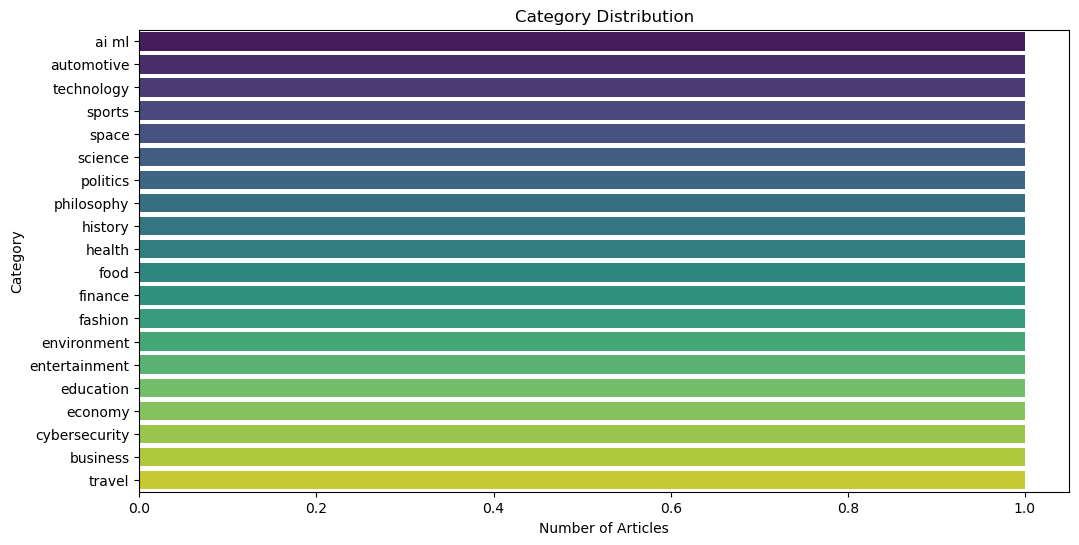

In [8]:
# Plot category distribution
plt.figure(figsize=(12, 6))
sns.countplot(y=df["category"], order=df["category"].value_counts().index, palette="viridis")
plt.xlabel("Number of Articles")
plt.ylabel("Category")
plt.title("Category Distribution")
plt.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22236\3057580219.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[word[0] for word in common_word], y=[word[1] for word in common_word], palette="magma")


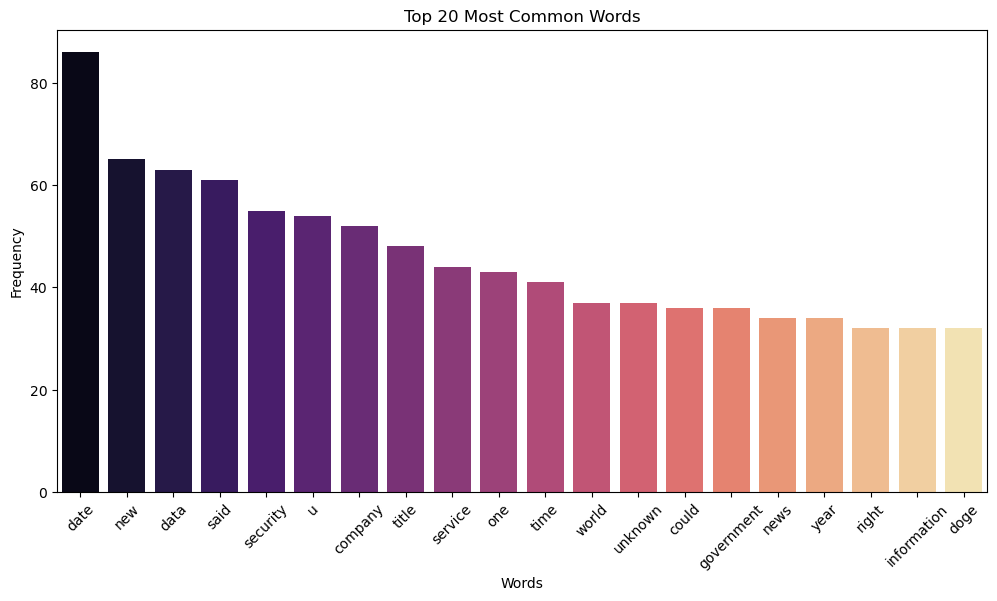

In [9]:
all_words = word_tokenize(" ".join(df["text"]))

word_counts = Counter(all_words)
common_word = word_counts.most_common(20)

# Plot word frequency
plt.figure(figsize=(12, 6))
sns.barplot(x=[word[0] for word in common_word], y=[word[1] for word in common_word], palette="magma")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Most Common Words")
plt.xticks(rotation=45)
plt.show()

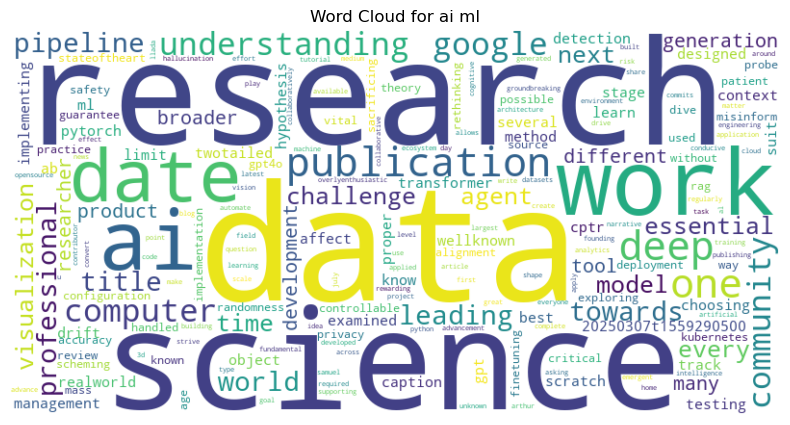

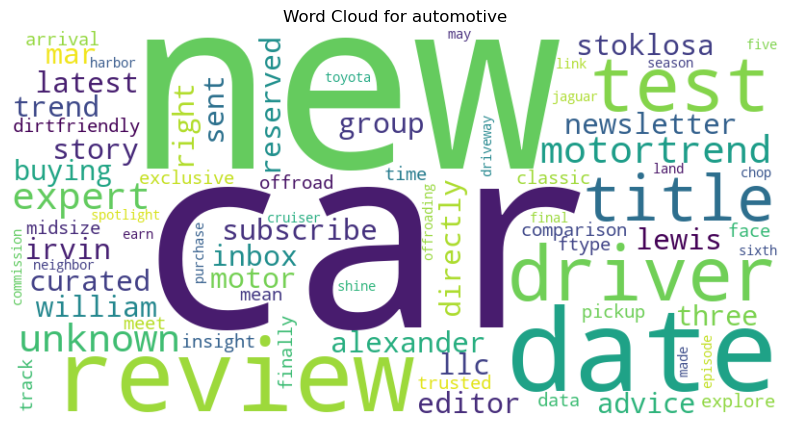

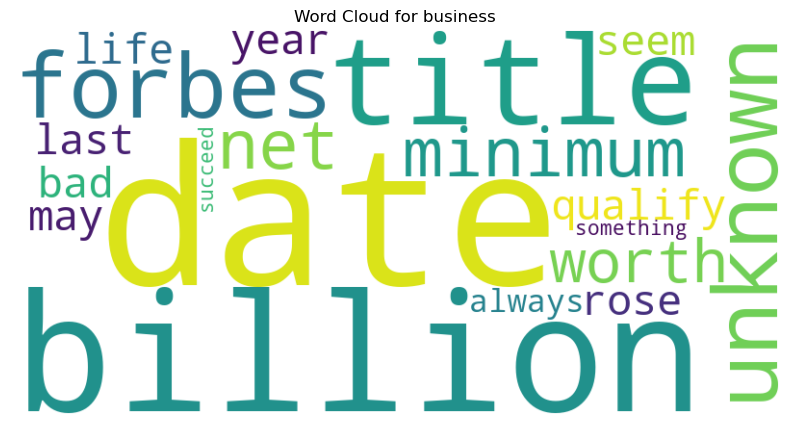

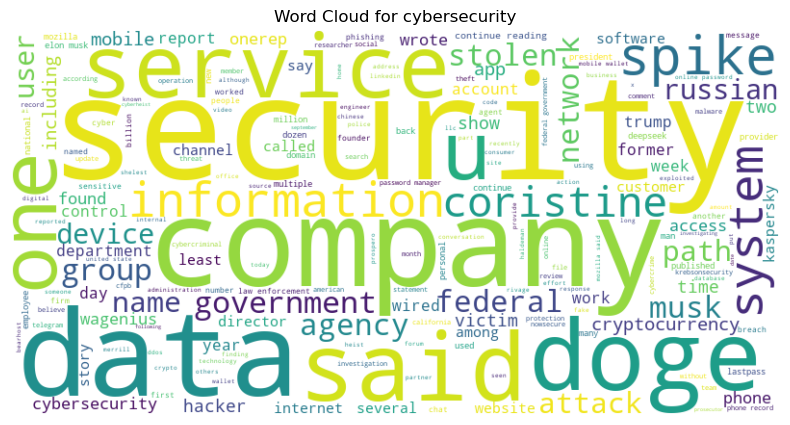

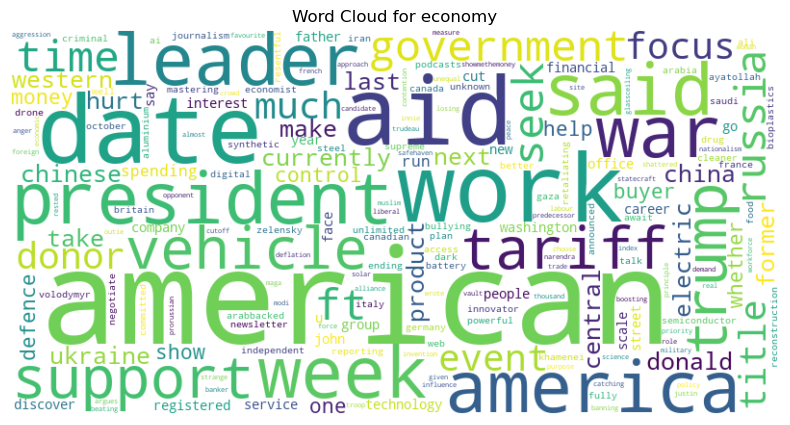

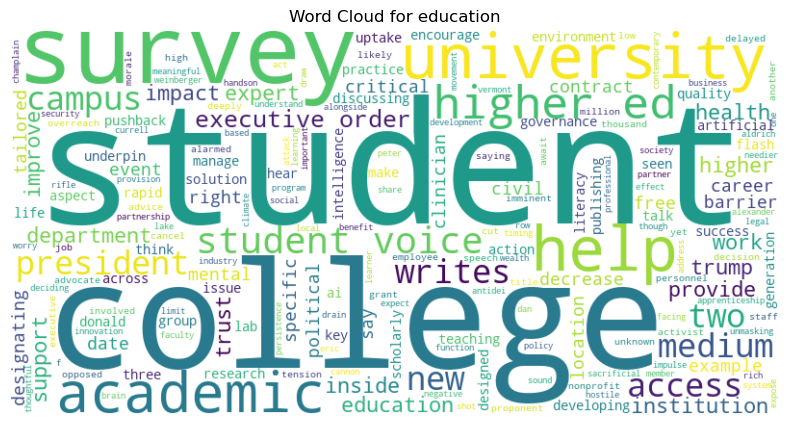

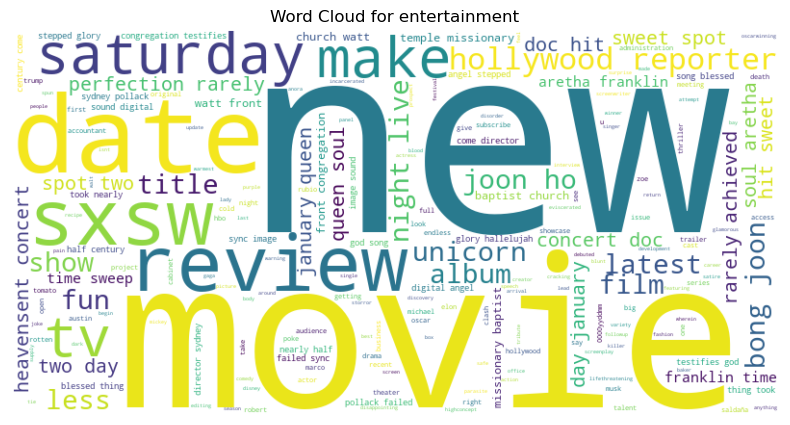

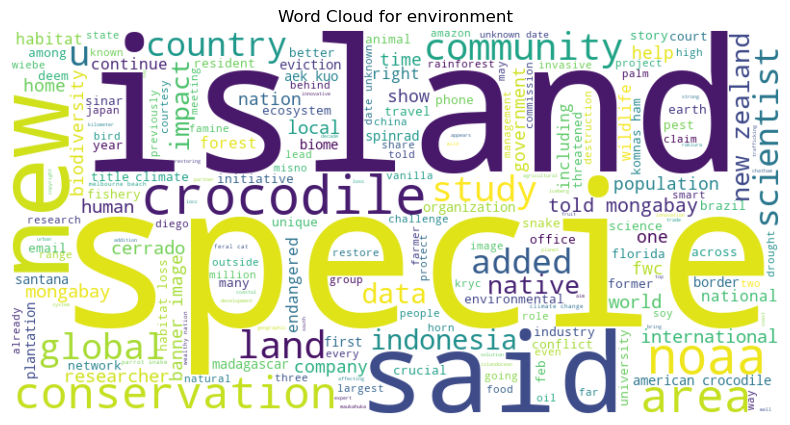

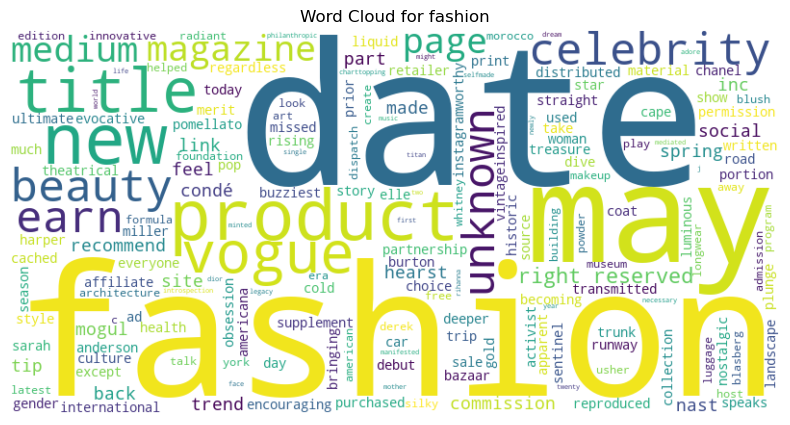

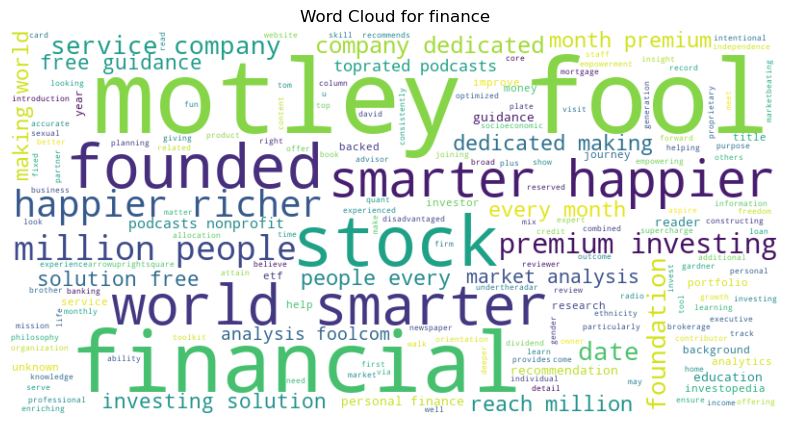

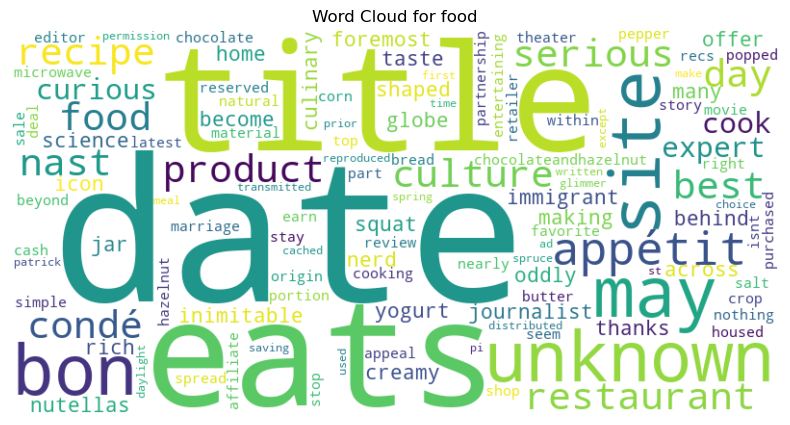

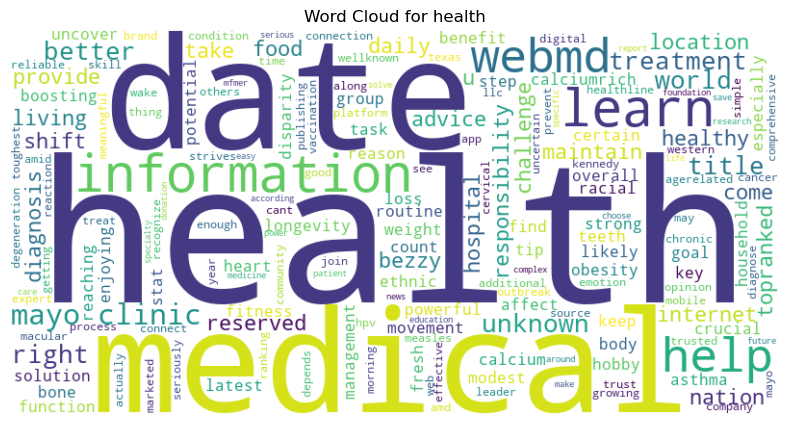

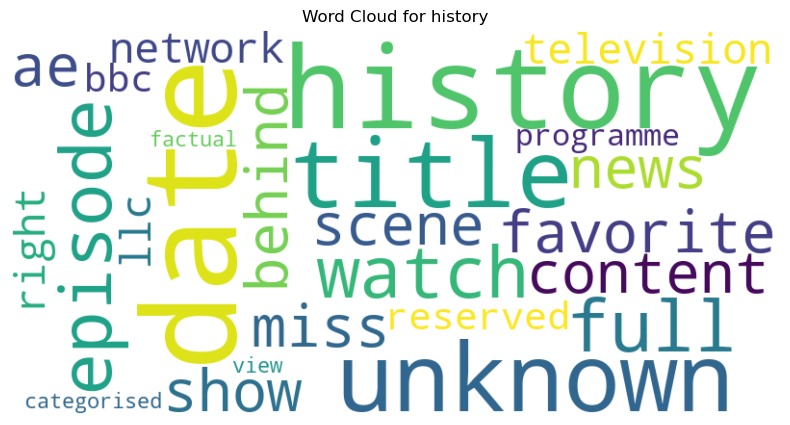

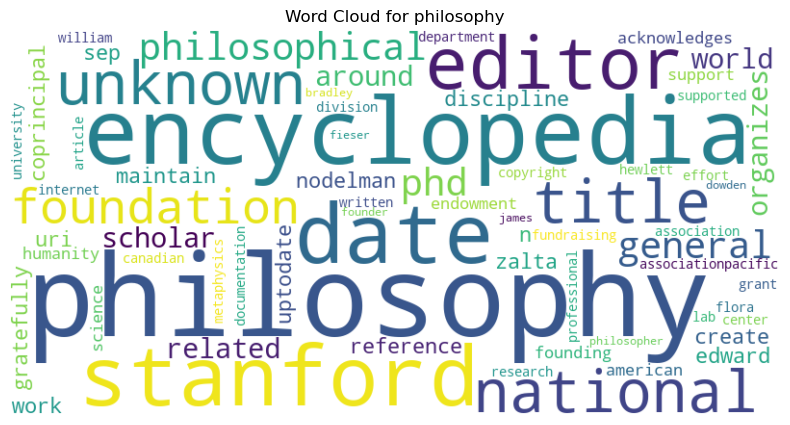

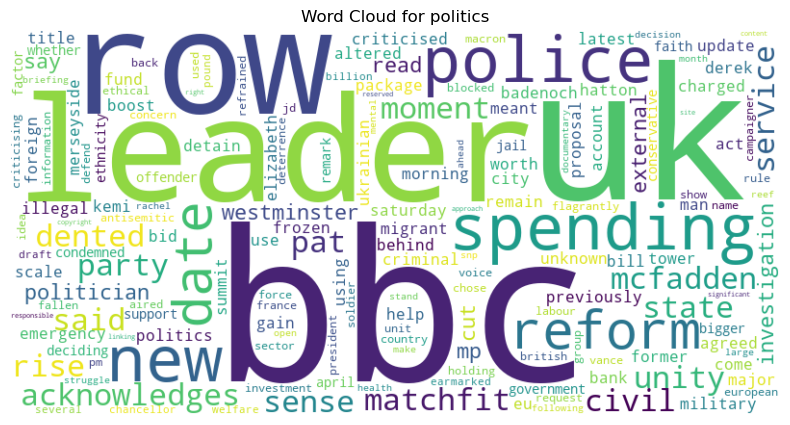

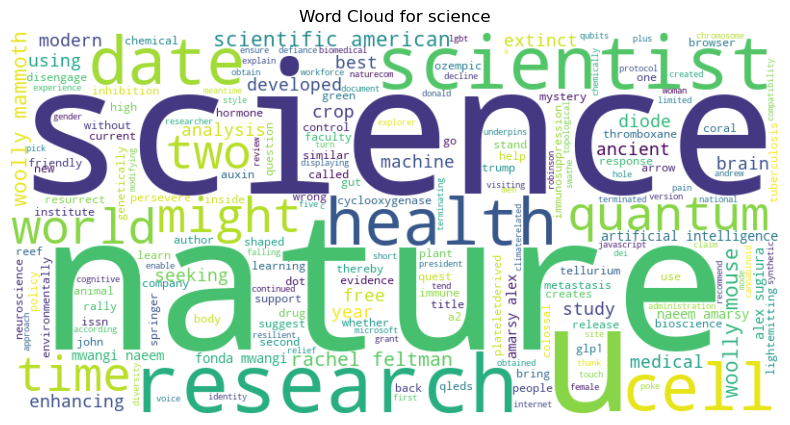

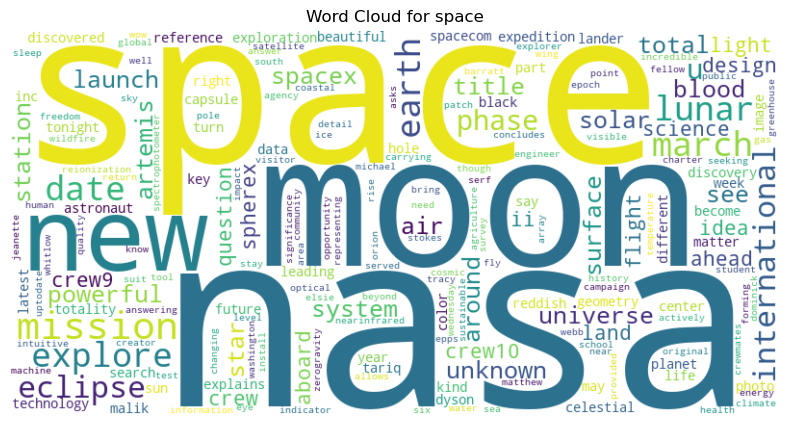

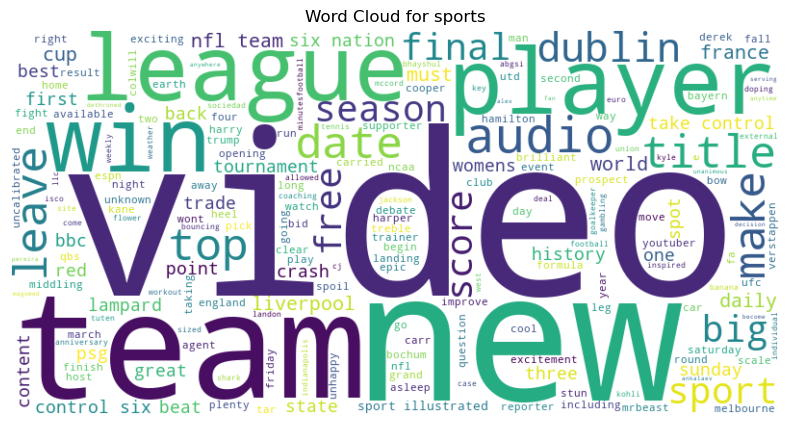

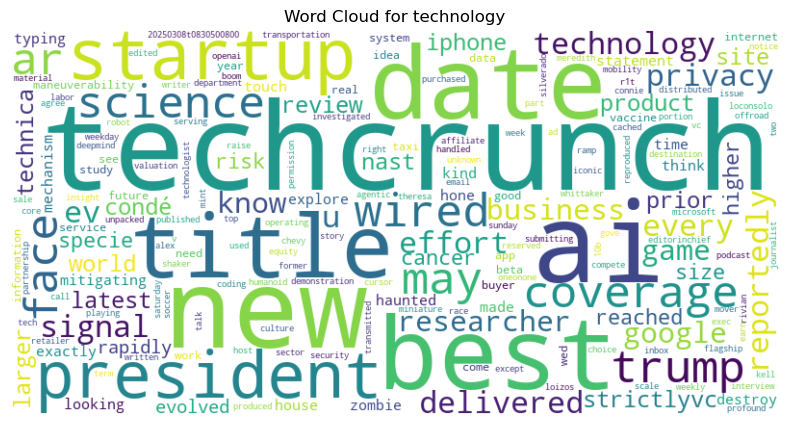

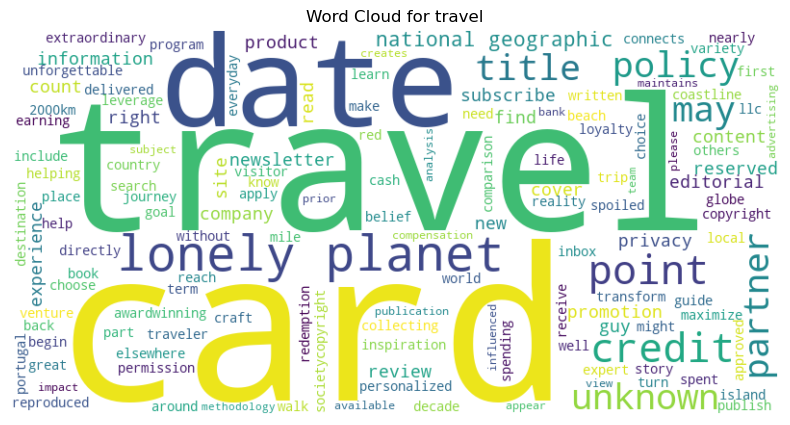

In [10]:
# Generate word clouds for each category
for category in df["category"].unique():
    text = " ".join(df[df["category"] == category]["text"])
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for {category}")
    plt.show()


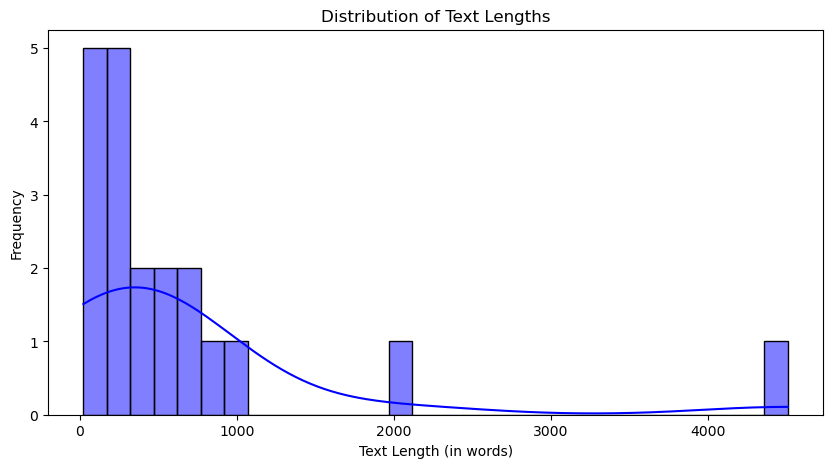

In [12]:
# Plot histogram of text lengths
plt.figure(figsize=(10, 5))
sns.histplot(df["text_length"], bins=30, kde=True, color="blue")
plt.xlabel("Text Length (in words)")
plt.ylabel("Frequency")
plt.title("Distribution of Text Lengths")
plt.show()


In [13]:
tfidf = TfidfVectorizer(max_features=20, stop_words="english")
X_tfidf = tfidf.fit_transform(df["text"])

# Convert to DataFrame
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
tfidf_df["category"] = df["category"]

# Find top words per category
top_tfidf = tfidf_df.groupby("category").mean().T
top_tfidf = top_tfidf.idxmax(axis=1)

print("Top Important Words Per Category (TF-IDF):")
print(top_tfidf)


Top Important Words Per Category (TF-IDF):
2025                  sports
company              finance
data                   ai ml
date                    food
doge           cybersecurity
government           economy
group              education
help               education
information           health
new            entertainment
news           entertainment
right                fashion
said             environment
security       cybersecurity
service              finance
time                 science
title                   food
unknown                 food
world                science
year                business
dtype: object


## Word2Vec:

In [43]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\ASUS\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [48]:
MAX_LEN = 512
from tqdm import tqdm

In [44]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text, padding="max_length", truncation=True, max_length=self.max_len, return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }

In [47]:
processed_texts = [item["text"] for item in processed_data]
categories = [item["category"] for item in processed_data]

# Convert category labels to numerical format
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(categories)  # Encode text labels to numbers

# Mapping for later use (category ↔ numerical label)
label_map = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

print("Example text:", processed_texts[0])
print("Example label (encoded):", labels[0])
print("Category Mapping:", label_map)

Example text: title towards data science date 20250307t1559290500 world leading publication data science ai ml professional examined several wellknown object detection pipeline designed one best suit data management gpt context limit realworld challenge implementing cptr caption transformer scratch pytorch 3 essential method track model drift know choosing one twotailed hypothesis affect every stage ab testing learn proper configuration implementation kubernetes probe vital critical deployment deep research handled stateoftheart review possible challenge research rethinking ai alignment safety age deep scheming exploring source randomness gpt4o known controllable deep dive way data used misinform mass guarantee patient privacy without sacrificing model accuracy theory practice understanding rag agent finetuning overlyenthusiastic application science data visualization question asking july 1959 arthur samuel developed one first agent play rewarding contributor time effort required write

In [49]:
dataset = TextDataset(processed_texts, labels, tokenizer, max_len=MAX_LEN)

In [50]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

In [51]:
BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [52]:
num_labels = len(set(labels))
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=num_labels)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [53]:
optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    model.train()
    train_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}"):
        optimizer.zero_grad()

        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        train_loss += loss.item()

        loss.backward()
        optimizer.step()
    
    print(f"Training Loss: {train_loss / len(train_loader)}")

c:\Users\ASUS\anaconda3\Lib\site-packages\transformers\optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Epoch 1: 100%|██████████| 2/2 [00:32<00:00, 16.42s/it]


Training Loss: 3.0657678842544556


Epoch 2: 100%|██████████| 2/2 [00:29<00:00, 14.58s/it]


Training Loss: 2.961307406425476


Epoch 3: 100%|██████████| 2/2 [00:26<00:00, 13.30s/it]


Training Loss: 2.8806965351104736


Epoch 4: 100%|██████████| 2/2 [00:29<00:00, 14.77s/it]


Training Loss: 2.8002874851226807


Epoch 5: 100%|██████████| 2/2 [00:29<00:00, 14.63s/it]

Training Loss: 2.771190881729126


In [54]:
model.eval()
predictions, true_labels = [], []

with torch.no_grad():
    for batch in tqdm(val_loader):
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        predictions.extend(torch.argmax(logits, dim=1).tolist())
        true_labels.extend(labels.tolist())

100%|██████████| 1/1 [00:01<00:00,  1.96s/it]


In [59]:
label_encoder = LabelEncoder()
label_encoder.fit([d["category"] for d in processed_data])

LabelEncoder()

In [61]:
print("Unique classes in true labels:", set(true_labels))
print("Unique classes in predictions:", set(predictions))
print("Total classes in label_map:", len(label_map.keys()))


Unique classes in true labels: {0, 1, 10, 13}
Unique classes in predictions: {8, 17, 13, 14}
Total classes in label_map: 20
